In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv(r"D:\ML\Data set/Breast_cancer.csv")

In [3]:
df_copy = df.copy()

In [4]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df_copy['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
df_copy.drop(columns=["Unnamed: 32"], inplace=True)

In [7]:
df_copy.drop(columns=["id"], inplace=True)

In [8]:
df_copy.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: >

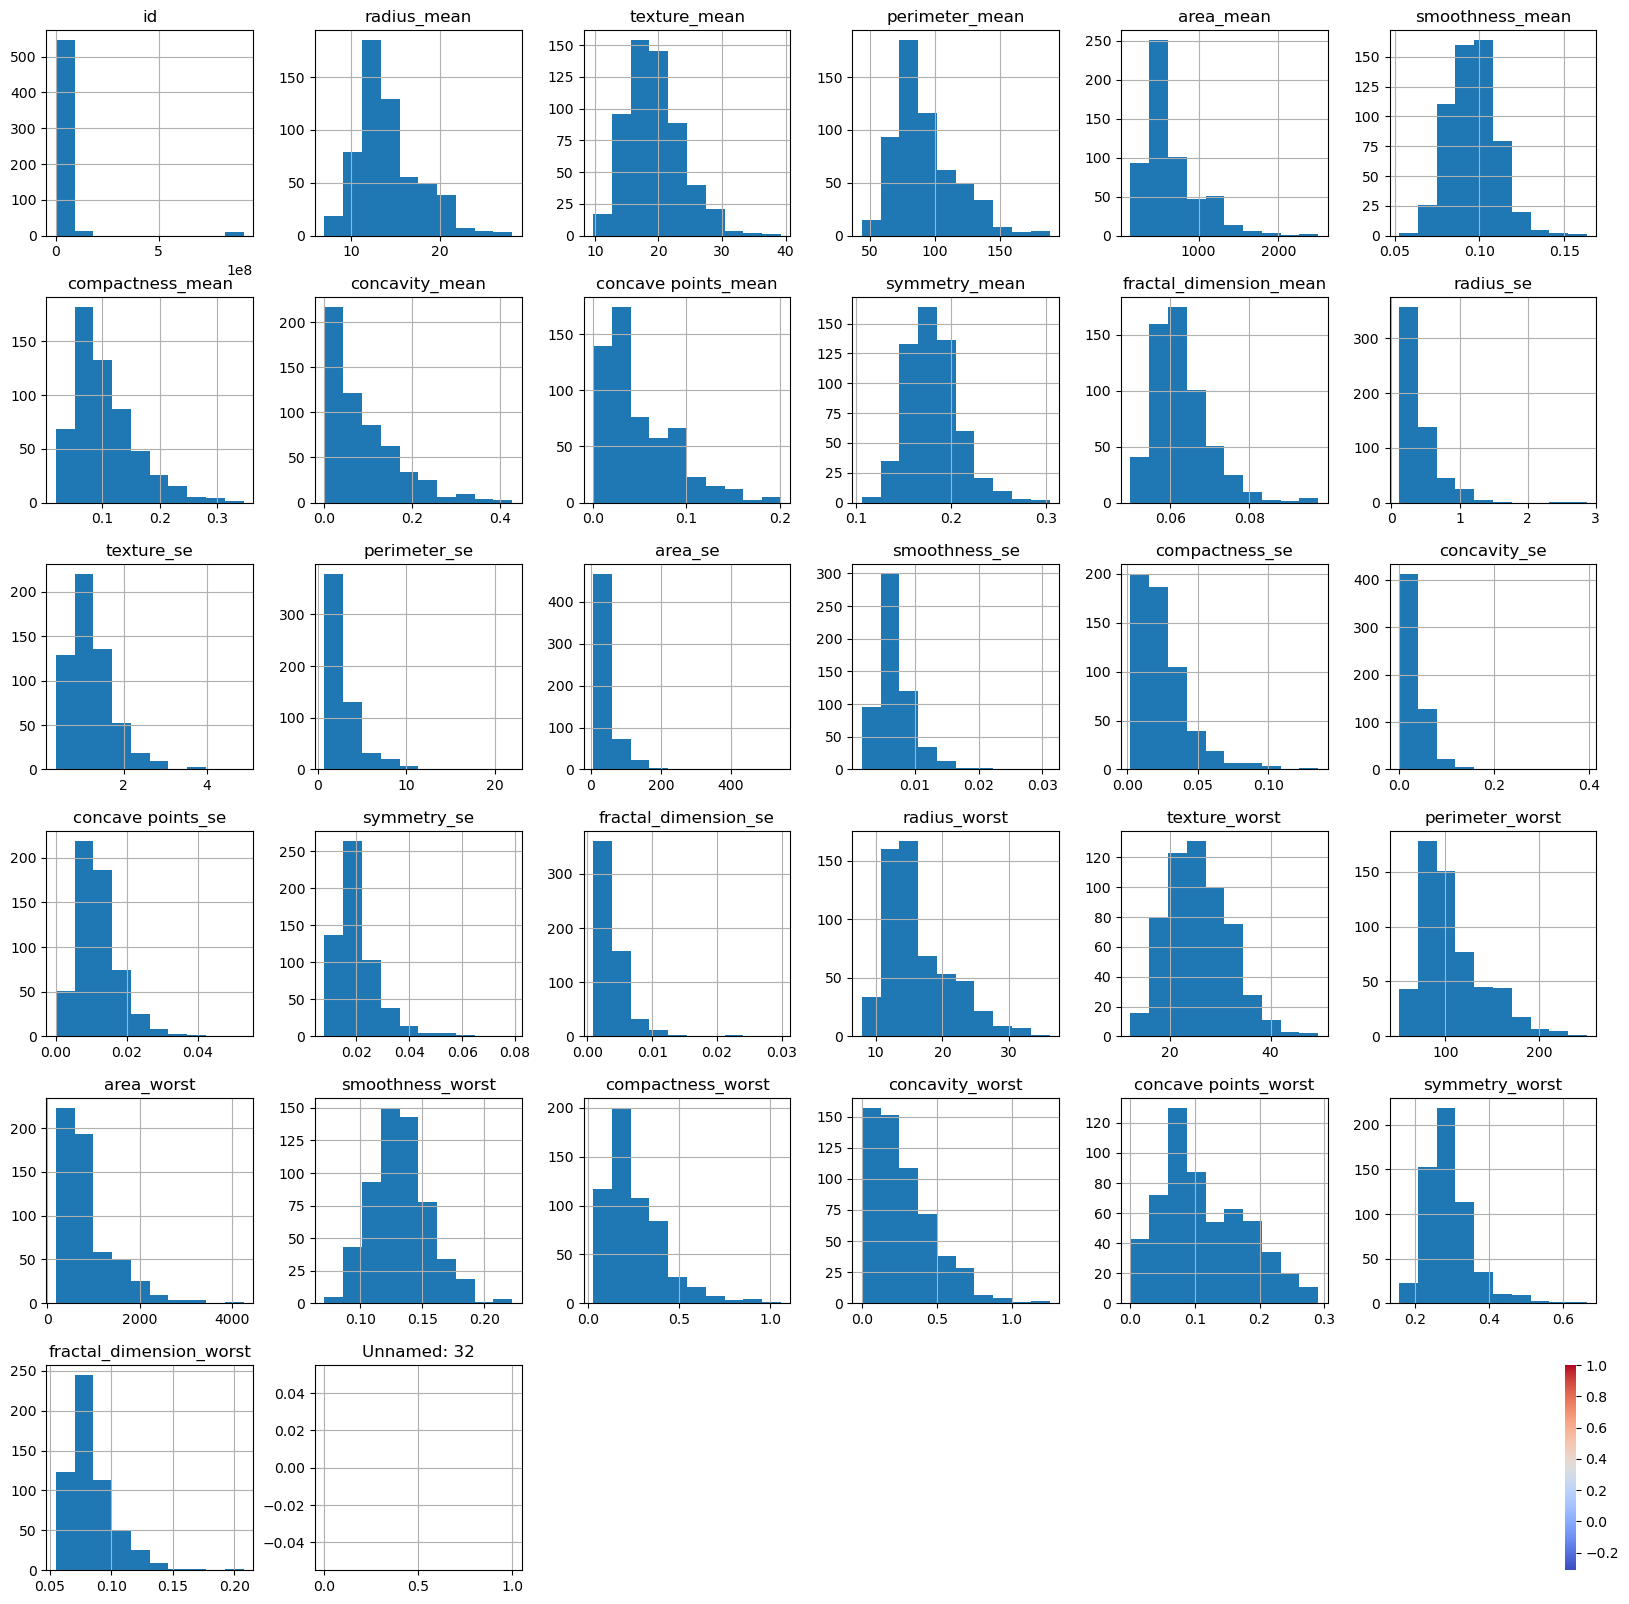

In [10]:


df.hist(figsize=(20,20))

df.skew(numeric_only=True)

sns.heatmap(df.drop(columns=["diagnosis"]).corr(), cmap="coolwarm")




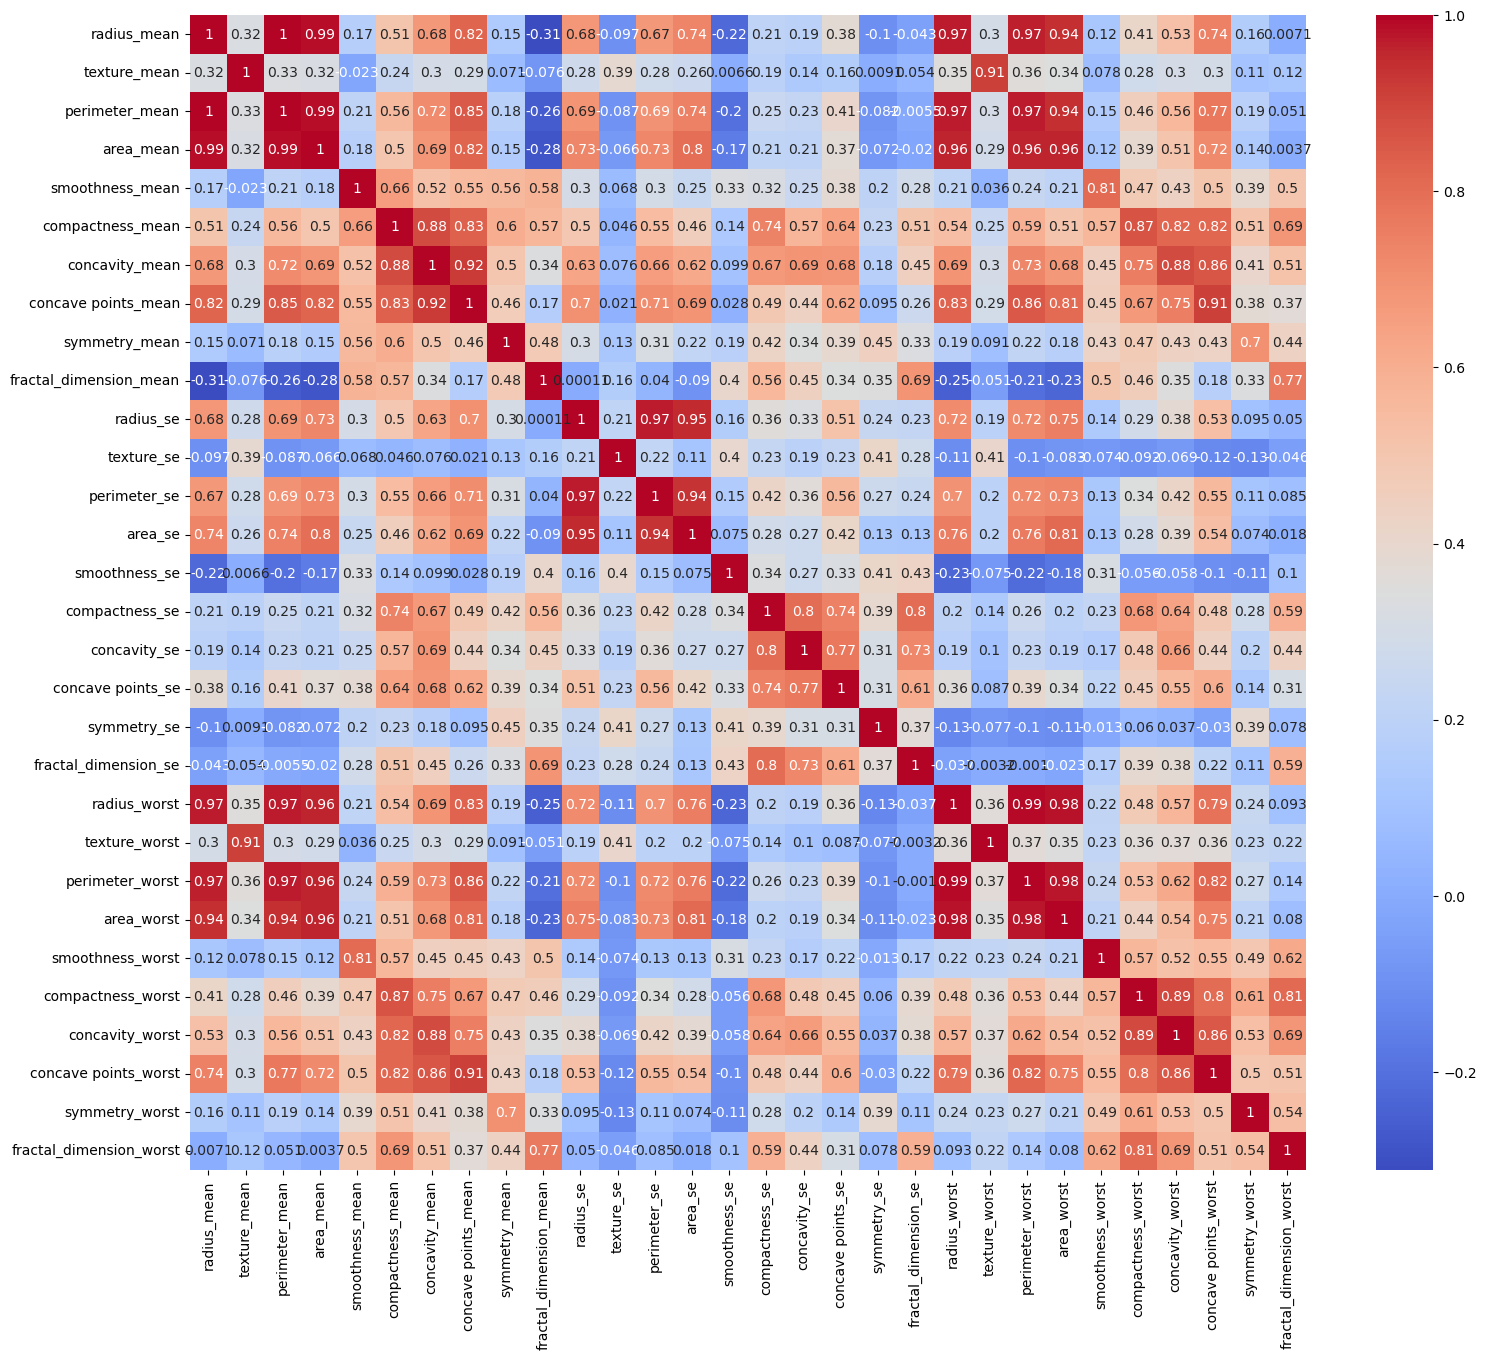

In [11]:
plt.figure(figsize=(18, 15))

sns.heatmap(
    df_copy.drop(columns=["diagnosis"]).corr(),
    cmap="coolwarm",
    annot=True
)

plt.show()

In [12]:
X = df_copy.drop(columns=["diagnosis"])

y = df_copy["diagnosis"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # Size of test and train data 20 - test , 80 - test
    random_state=42,   # Help to reusebilty so we get the same answers every time we run the code 
    shuffle=True,      # default, but can be explicit
    stratify=y         # keeps class proportions
)

In [14]:
y.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [17]:
print("Original Features:", X_train.shape[1])
print("PCA Features:", X_train_pca.shape[1])

Original Features: 30
PCA Features: 10


In [18]:
print(pca.explained_variance_ratio_)

[0.44593522 0.18545255 0.09584641 0.06593768 0.05622286 0.03988488
 0.02214493 0.01614006 0.01284789 0.01165661]


In [19]:
import numpy as np

print(np.sum(pca.explained_variance_ratio_))

0.9520691014391004


In [20]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train_pca, y_train)

,priors,None
,var_smoothing,1e-09


In [21]:
y_pred = model.predict(X_test_pca)

In [22]:
y_prob = model.predict_proba(X_test_pca)

In [23]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8947368421052632

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[66  6]
 [ 6 36]]


In [25]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob[:,1])

0.9613095238095238